In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
seg = pd.read_csv('data/stocks/stocks_segmentos.csv')
df_res = pd.read_csv('df_pesos.csv')

seg.head()

,Ticker,Setor
0,UNIP3.SA,Basic Materials
1,MDIA3.SA,Consumer Defensive
2,AFLT3.SA,Utilities
3,BALM3.SA,Healthcare
4,MSFT34.SA,Technology


In [36]:
colunas_sa = [col for col in df_res.columns if col.endswith('.SA')]

colunas_finais = ['Data'] + colunas_sa

df_filtrado = df_res[colunas_finais]
df_periodo = df_filtrado[(df_filtrado['Data'] >= '2021-01-01') & (df_filtrado['Data'] <= '2022-12-31')]
df_grafico = df_periodo.set_index('Data')[colunas_sa]

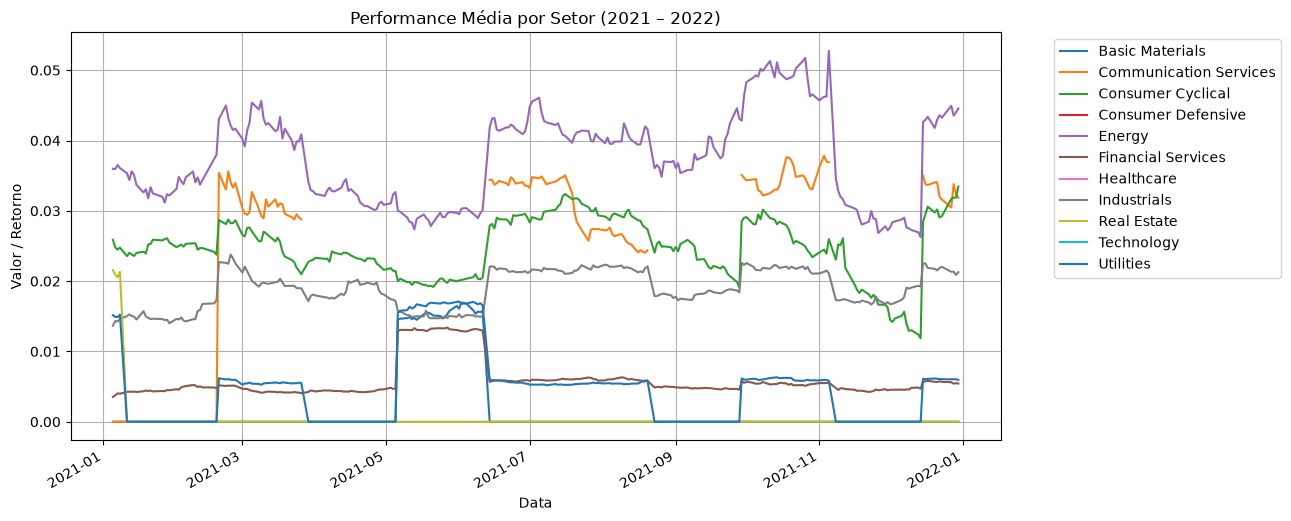

In [37]:
df_res['Data'] = pd.to_datetime(df_res['Data'])
df_periodo = df_res[(df_res['Data'] >= '2021-01-01') & (df_res['Data'] <= '2021-12-31')].copy()

# 2. Transformar de formato 'wide' para 'long'
df_long = df_periodo.melt(
    id_vars=['Data'],
    value_vars=colunas_sa,
    var_name='Ticker',
    value_name='Valor'
)

# 3. Cruzar com a base de setores
df_merged = df_long.merge(seg, on='Ticker', how='left')

# 4. Agregar por Data e Setor (média simples dos ativos do setor)
df_setores = (
    df_merged
    .groupby(['Data', 'Setor'])['Valor']
    .mean()
    .unstack()
)

# 5. Plotar a evolução temporal dos setores
df_setores.plot(figsize=(12, 6))
plt.title('Performance Média por Setor (2021 – 2022)')
plt.ylabel('Valor / Retorno')
plt.xlabel('Data')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

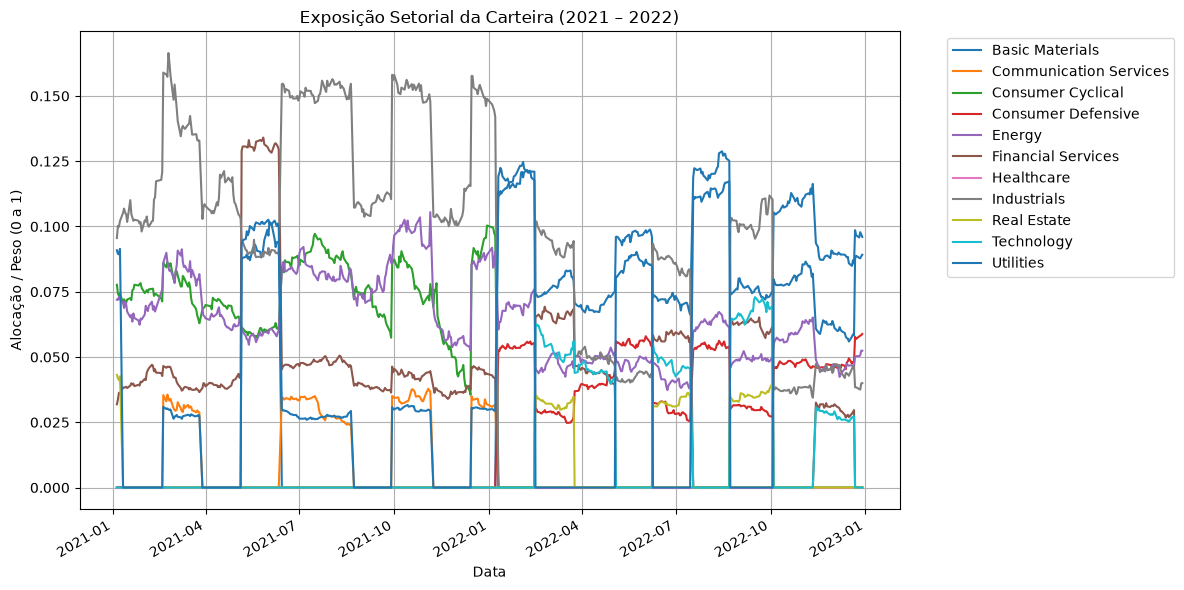

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtro de datas
df_res['Data'] = pd.to_datetime(df_res['Data'])
df_periodo = df_res[(df_res['Data'] >= '2021-01-01') & (df_res['Data'] <= '2022-12-31')].copy()

# 2. Dicionário de mapeamento: {'UGPA3.SA': 'Energy', 'VALE3.SA': 'Basic Materials', ...}
mapa_setor = seg.set_index('Ticker')['Setor'].to_dict()

# 3. Agrupar as colunas de ações pelo setor e somar a exposição
# (O .T transpõe para agrupar por setor de forma compatível com todas as versões do pandas)
df_setores = (
    df_periodo.set_index('Data')[colunas_sa]
    .T
    .groupby(mapa_setor)
    .sum()
    .T
)

# 4. Plotar a evolução da alocação setorial
df_setores.plot(figsize=(12, 6))
plt.title('Exposição Setorial da Carteira (2021 – 2022)')
plt.ylabel('Alocação / Peso (0 a 1)')
plt.xlabel('Data')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/hw/b2dz7zcs57v20rl56mjhqmbr0000gn/T/ipykernel_73491/4289279484.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long_mensal, x='Setor', y='Peso_Medio', palette='Blues_d', showmeans=True)


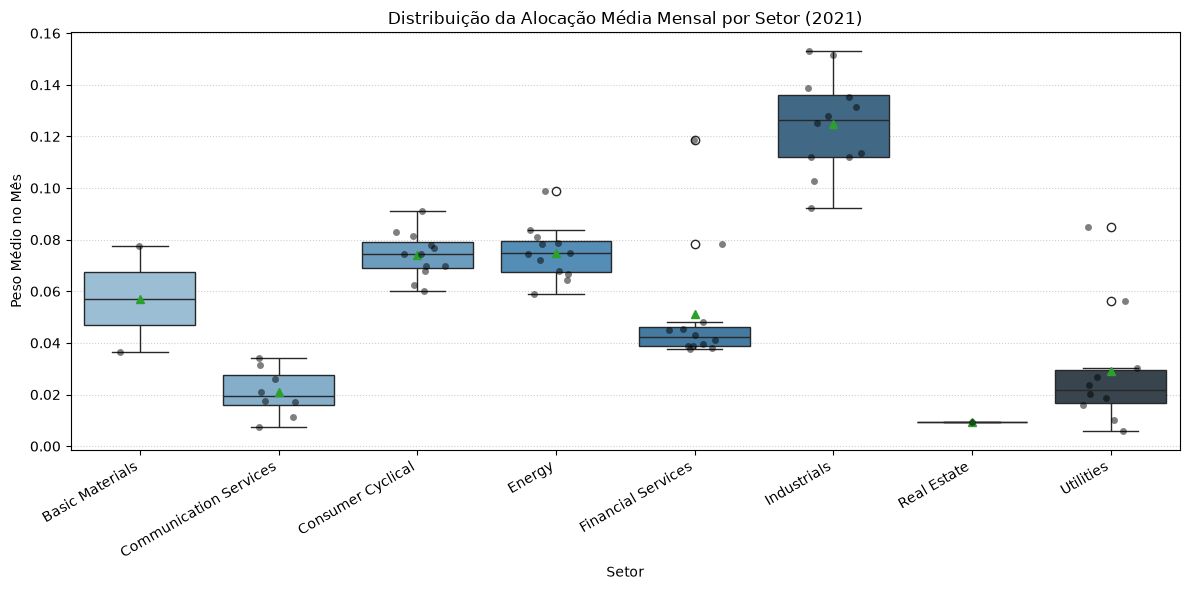

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar as bases
df_pesos = pd.read_csv('df_pesos.csv')
seg = pd.read_csv('data/stocks/stocks_segmentos.csv')

# 2. Ajustar datas e filtrar o período 2021-2022
df_pesos['Data'] = pd.to_datetime(df_pesos['Data'])
df_per = df_pesos[(df_pesos['Data'] >= '2021-01-01') & (df_pesos['Data'] <= '2021-12-31')].copy()

# 3. Mapear Ticker -> Setor (ignorando a coluna 'CDI')
mapa_setor = seg.set_index('Ticker')['Setor'].to_dict()
colunas_ativos = [c for c in df_per.columns if c.endswith('.SA')]

# 4. Exposição diária acumulada por setor (agrega somando os pesos das ações do setor)
df_setores_diario = (
    df_per.set_index('Data')[colunas_ativos]
    .T
    .groupby(mapa_setor)
    .sum()
    .T
)

# 5. Agregação Mensal (Peso Médio alocado no mês por setor)
df_setores_mensal = df_setores_diario.resample('ME').mean()

# Formato longo filtrando meses em que o setor de fato esteve na carteira
df_long_mensal = df_setores_mensal.melt(var_name='Setor', value_name='Peso_Medio')
df_long_mensal = df_long_mensal[df_long_mensal['Peso_Medio'] > 0.005] # Apenas posições ativas

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_long_mensal, x='Setor', y='Peso_Medio', palette='Blues_d', showmeans=True)
sns.stripplot(data=df_long_mensal, x='Setor', y='Peso_Medio', color='black', alpha=0.5, jitter=0.2)
plt.title('Distribuição da Alocação Média Mensal por Setor (2021)')
plt.ylabel('Peso Médio no Mês')
plt.xlabel('Setor')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

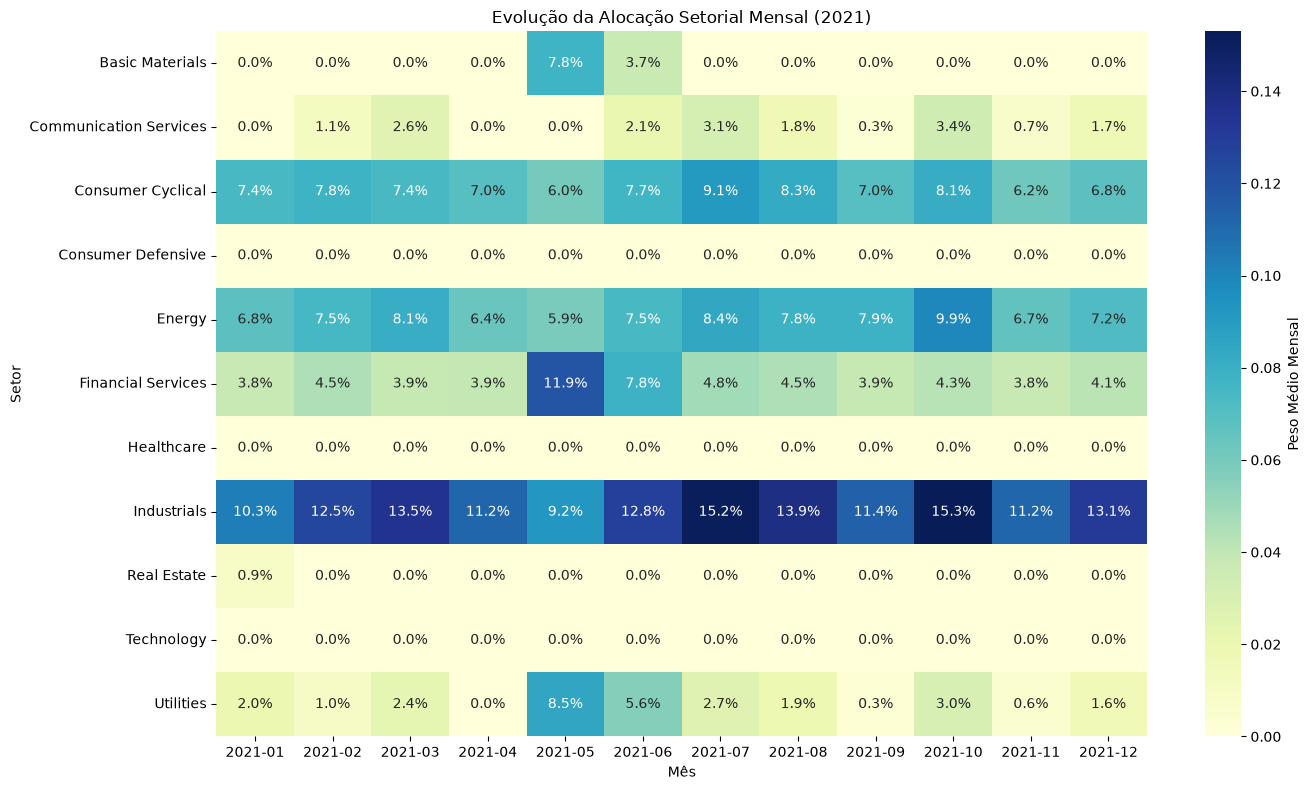

In [42]:
heatmap_df = df_setores_mensal.copy()
heatmap_df.index = heatmap_df.index.strftime('%Y-%m')

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_df.T, 
    cmap='YlGnBu', 
    annot=True, 
    fmt='.1%', 
    cbar_kws={'label': 'Peso Médio Mensal'}
)
plt.title('Evolução da Alocação Setorial Mensal (2021)')
plt.xlabel('Mês')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

In [44]:
resumo_consistencia = pd.DataFrame({
    'Meses Posicionado (Total 12)': (df_setores_mensal > 0.005).sum(),
    'Freq. de Alocação (%)': ((df_setores_mensal > 0.005).mean() * 100).round(1),
    'Peso Médio (Quando Ativo)': df_setores_mensal[df_setores_mensal > 0.005].mean().round(4),
    'Peso Máximo Atingido': df_setores_mensal.max().round(4),
    'Desvio Padrão do Peso': df_setores_mensal[df_setores_mensal > 0.005].std().round(4)
}).sort_values(by='Meses Posicionado (Total 12)', ascending=False)

print(resumo_consistencia)

                        Meses Posicionado (Total 12)  Freq. de Alocação (%)  \
Consumer Cyclical                                 12                  100.0   
Energy                                            12                  100.0   
Financial Services                                12                  100.0   
Industrials                                       12                  100.0   
Utilities                                         10                   83.3   
Communication Services                             8                   66.7   
Basic Materials                                    2                   16.7   
Real Estate                                        1                    8.3   
Consumer Defensive                                 0                    0.0   
Healthcare                                         0                    0.0   
Technology                                         0                    0.0   

                        Peso Médio (Quando Ativo)  

In [45]:
df_pesos['Data'] = pd.to_datetime(df_pesos['Data'])
df_2021 = df_pesos[(df_pesos['Data'] >= '2021-01-01') & (df_pesos['Data'] <= '2021-12-31')].copy()

mapa_setor = seg.set_index('Ticker')['Setor'].to_dict()
cols_sa = [c for c in df_2021.columns if c.endswith('.SA')]

# 2. Exposição agregada por setor
df_setores_2021 = (
    df_2021.set_index('Data')[cols_sa]
    .T
    .groupby(mapa_setor)
    .sum()
    .T
)

# Adiciona o CDI para enxergar o caixa/hedge
df_setores_2021['CDI_Caixa'] = df_2021.set_index('Data')['CDI']

<Figure size 1400x700 with 0 Axes>

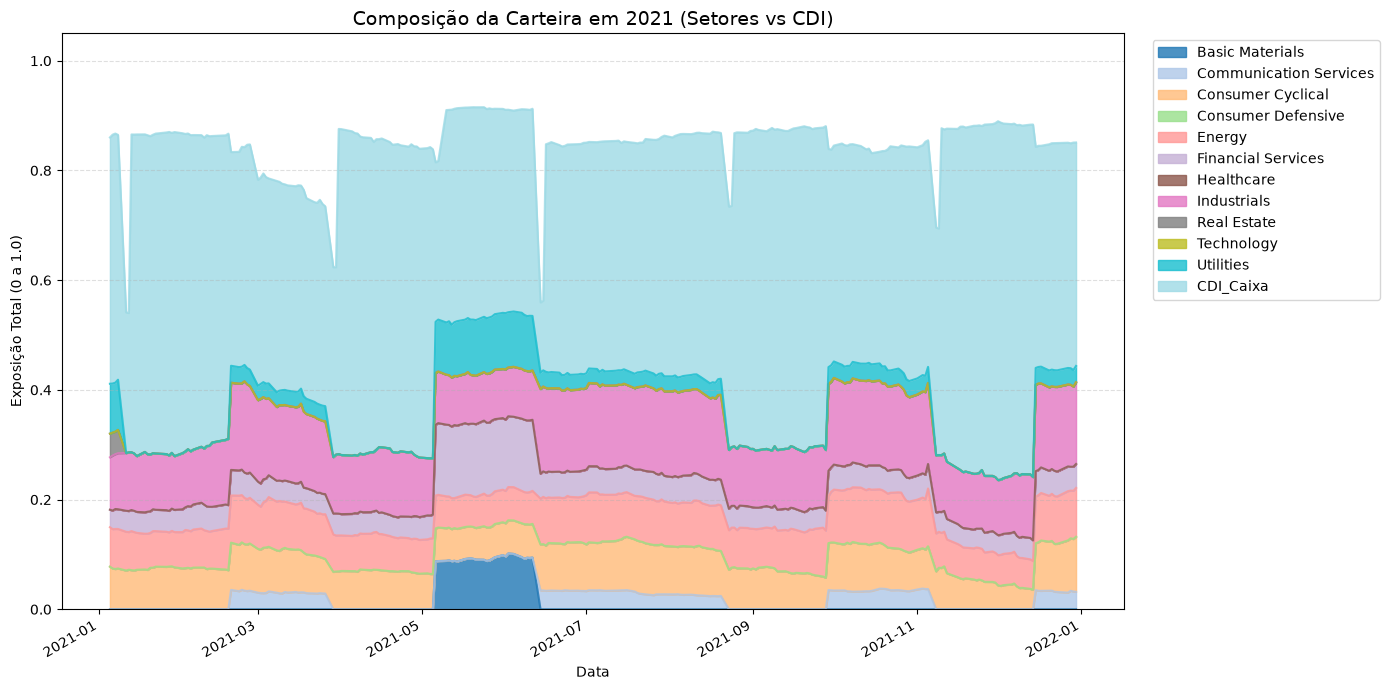

In [46]:
plt.figure(figsize=(14, 7))
df_setores_2021.plot.area(figsize=(14, 7), alpha=0.8, colormap='tab20')
plt.title('Composição da Carteira em 2021 (Setores vs CDI)', fontsize=14)
plt.ylabel('Exposição Total (0 a 1.0)')
plt.xlabel('Data')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/hw/b2dz7zcs57v20rl56mjhqmbr0000gn/T/ipykernel_73491/3166561803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_2021[resumo_2021['Setor'] != 'CDI_Caixa'], x='Peso_Medio', y='Setor', palette='Reds_r')


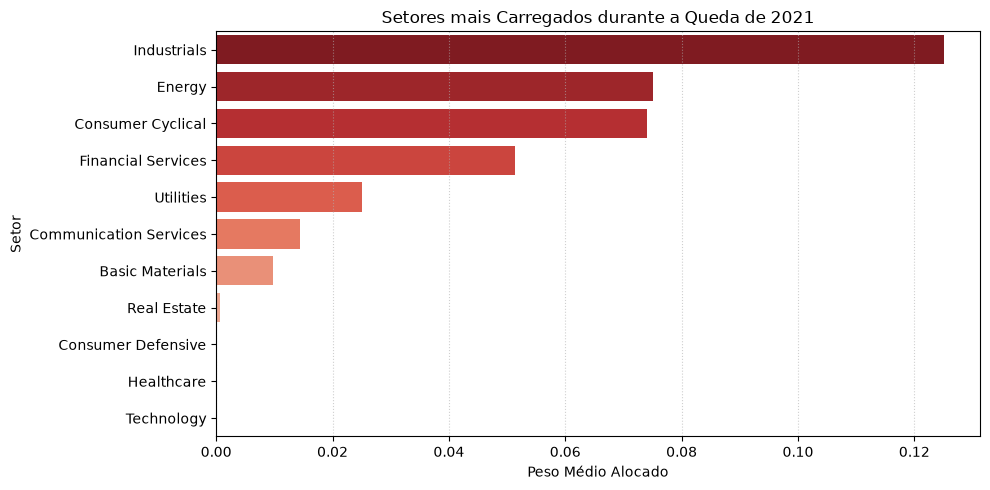

In [47]:
resumo_2021 = (
    df_setores_2021.mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'index': 'Setor', 0: 'Peso_Medio'})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=resumo_2021[resumo_2021['Setor'] != 'CDI_Caixa'], x='Peso_Medio', y='Setor', palette='Reds_r')
plt.title('Setores mais Carregados durante a Queda de 2021')
plt.xlabel('Peso Médio Alocado')
plt.ylabel('Setor')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()